In [12]:
from lab1.src.constant.fetching import RESULTS
%pip install feedparser pandas fastparquet bs4 pypdf2 pdfplumber sentence-transformers faiss-cpu transformers rapidfuzz symspellpy yake networkx matplotlib scipy seaborn textblob stanza nltk

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1) Выбрать тематику для поиска

In [13]:
from lab1.src.constant.arxiv import CATEGORY
%pip install arxiv

import arxiv
import pandas as pd


def fetch_arxiv_papers(category, max_results=100):
    papers = []

    client = arxiv.Client()

    search = arxiv.Search(
        query=f"cat:{category}",
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate,
        sort_order=arxiv.SortOrder.Descending
    )

    try:
        for result in client.results(search):
            paper = {
                "id": result.entry_id,
                "title": result.title,
                "authors": [author.name for author in result.authors],
                "summary": result.summary,
                "published": result.published.strftime("%Y-%m-%d"),
                "pdf_url": result.pdf_url
            }
            papers.append(paper)
            print(f"Загружена: {result.title[:60]}...")

    except Exception as e:
        print(f"Ошибка при загрузке: {e}")

    return papers


papers = fetch_arxiv_papers(CATEGORY, max_results=RESULTS)
print(f"Успешно загружено {len(papers)} статей")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Загружена: Deep infant brain segmentation from multi-contrast MRI...
Загружена: Multi Task Denoiser Training for Solving Linear Inverse Prob...
Загружена: Structure-Aware Adaptive Kernel MPPCA Denoising for Diffusio...
Загружена: Ultra-lightweight Neural Video Representation Compression...
Загружена: Tada-DIP: Input-adaptive Deep Image Prior for One-shot 3D Im...
Загружена: A BTR-Based Approach for Detection of Infrared Small Targets...
Загружена: Real-Time Control and Automation Framework for Acousto-Holog...
Загружена: Kaleidoscopic Scintillation Event Imaging...
Загружена: Quality assurance of the Federal Interagency Traumatic Brain...
Загружена: Ultra-Strong Gradient Diffusion MRI with Self-Supervised Lea...
Загружена: Maintaining SUV Accuracy in Low-Count PET with PETfectior: A...
Загружена: Towards Languag

In [14]:
df = pd.DataFrame(papers)
print(f"Размер DataFrame: {df.shape}")

df[['title', 'authors', 'summary']].head(3)

Размер DataFrame: (250, 6)


,title,authors,summary
0,Deep infant brain segmentation from multi-cont...,"[Malte Hoffmann, Lilla Zöllei, Adrian V. Dalca]",Segmentation of magnetic resonance images (MRI...
1,Multi Task Denoiser Training for Solving Linea...,"[Clément Bled, François Pitié]",Plug-and-Play Priors (PnP) and Regularisation ...
2,Structure-Aware Adaptive Kernel MPPCA Denoisin...,"[Ananya Singhal, Dattesh Dayanand Shanbhag, Su...",Diffusion-weighted MRI (DWI) at high b-values ...


In [15]:
df.to_parquet('eess_iv_raw.parquet.gzip', compression='gzip')
print("Данные сохранены в eess_iv_raw.parquet.gzip")

Данные сохранены в eess_iv_raw.parquet.gzip


## 2) Разбиение на чанки

In [16]:
def split_into_chunks(text, chunk_size=135, overlap=14):
    words = text.split()
    chunks = []
    start = 0

    while start < len(words):
        end = start + chunk_size
        chunk = words[start:end]
        chunks.append(" ".join(chunk))
        start += chunk_size - overlap

    return chunks


def create_chunks_dataframe(df, chunk_size=500, overlap=50):
    chunks_data = []

    for idx, row in df.iterrows():
        article_id = idx
        title = row['title']
        authors = ", ".join(row['authors'])
        summary = row['summary']

        summary_chunks = split_into_chunks(summary, chunk_size, overlap)

        for chunk_idx, chunk_text in enumerate(summary_chunks):
            chunks_data.append({
                'article_id': article_id,
                'chunk_id': chunk_idx,
                'title': title,
                'authors': authors,
                'chunk_text': chunk_text,
                'chunk_length': len(chunk_text.split())
            })

    return pd.DataFrame(chunks_data)


df_chunks = create_chunks_dataframe(df)
print(f"Создано {len(df_chunks)} чанков из {len(df)} статей")
print(f"Средняя длина чанка: {df_chunks['chunk_length'].mean():.1f} слов")

df_chunks.head()

Создано 250 чанков из 250 статей
Средняя длина чанка: 186.8 слов


,article_id,chunk_id,title,authors,chunk_text,chunk_length
0,0,0,Deep infant brain segmentation from multi-cont...,"Malte Hoffmann, Lilla Zöllei, Adrian V. Dalca",Segmentation of magnetic resonance images (MRI...,199
1,1,0,Multi Task Denoiser Training for Solving Linea...,"Clément Bled, François Pitié",Plug-and-Play Priors (PnP) and Regularisation ...,177
2,2,0,Structure-Aware Adaptive Kernel MPPCA Denoisin...,"Ananya Singhal, Dattesh Dayanand Shanbhag, Sud...",Diffusion-weighted MRI (DWI) at high b-values ...,80
3,3,0,Ultra-lightweight Neural Video Representation ...,"Ho Man Kwan, Tianhao Peng, Ge Gao, Fan Zhang, ...",Recent works have demonstrated the viability o...,209
4,4,0,Tada-DIP: Input-adaptive Deep Image Prior for ...,"Evan Bell, Shijun Liang, Ismail Alkhouri, Saip...",Deep Image Prior (DIP) has recently emerged as...,109


## 3) Векторизация текста

In [17]:
from sentence_transformers import SentenceTransformer
import faiss

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

texts_to_embed = df_chunks['chunk_text'].tolist()

print(f"Векторизация {len(texts_to_embed)} чанков...")
embeddings = model.encode(texts_to_embed, show_progress_bar=True, convert_to_numpy=True)

print(f"Размерность эмбеддингов: {embeddings.shape}")

Векторизация 250 чанков...


Batches: 100%|██████████| 8/8 [00:00<00:00, 23.07it/s]

Размерность эмбеддингов: (250, 384)


In [18]:
embedding_dim = embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dim)
index.add(embeddings)

print(f"FAISS индекс создан. Количество векторов: {index.ntotal}")

faiss.write_index(index, "eess_iv_index.faiss")
df_chunks.to_parquet("eess_iv_chunks.parquet.gzip", compression="gzip")

print("Векторное хранилище сохранено")

FAISS индекс создан. Количество векторов: 250
Векторное хранилище сохранено


## 4) Интеграция с LLM

In [19]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from symspellpy import SymSpell

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

print("Загрузка FLAN-T5 модели...")
flan_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
flan_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")

Загрузка FLAN-T5 модели...


## 5) Поиск по корпусу

In [26]:
%pip install rapidfuzz symspellpy

from symspellpy import SymSpell, Verbosity
import pkg_resources

technical_terms = [
    "deep", "learning", "machine", "neural", "network", "image", "segmentation",
    "medical", "analysis", "approaches", "summarize", "recent", "advances",
    "processing", "current", "trends", "computer", "vision", "research",
    "classification", "methods", "object", "detection", "transformer",
    "convolutional", "super", "resolution", "feature", "extraction",
    "vision", "transformer", "architectures", "attention", "mechanism",
    "convolution", "pooling", "activation", "function", "optimizer",
    "backpropagation", "gradient", "descent", "loss", "function",
    "accuracy", "precision", "recall", "f1", "score", "metric"
]


def correct_spelling(query):
    sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

    try:
        dictionary_path = pkg_resources.resource_filename(
            "symspellpy", "frequency_dictionary_en_82_765.txt"
        )
        sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
    except:
        print("Используем кастомный словарь...")
        for term in technical_terms:
            sym_spell.create_dictionary_entry(term, 1000)
        common_words = ["what", "are", "for", "in", "do", "how", "work", "the", "and",
                        "with", "using", "based", "from", "this", "that", "which"]
        for word in common_words:
            sym_spell.create_dictionary_entry(word, 2000)

    suggestions = sym_spell.lookup_compound(query, max_edit_distance=2)
    if suggestions:
        return suggestions[0].term
    return query


def search_similar_chunks(query, top_k=3):
    query_embedding = model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_embedding, top_k)

    results = []
    for i, idx in enumerate(indices[0]):
        chunk_data = df_chunks.iloc[idx].to_dict()
        chunk_data['distance'] = distances[0][i]
        results.append(chunk_data)

    return results


def create_rag_prompt(query, context_chunks, prompt_type="qa"):
    context_text = "\n".join([
        f"Article: {chunk['title']}\nText: {chunk['chunk_text']}"
        for chunk in context_chunks[:2]
    ])

    prompts = {
        "qa": f"""Answer based on these articles:

{context_text}

Question: {query}

Answer:""",

        "summary": f"""Summarize main points:

{context_text}

Summary:""",

        "comparison": f"""Compare approaches:

{context_text}

Comparison:""",

        "methods": f"""What methods are used?

{context_text}

Methods:""",

        "trends": f"""What trends are shown?

{context_text}

Trends:"""
    }

    return prompts.get(prompt_type, prompts["qa"])


def ask_flan_rag(query, prompt_type="qa", top_k=3):
    corrected_query = correct_spelling(query)
    context_chunks = search_similar_chunks(corrected_query, top_k)

    prompt = create_rag_prompt(corrected_query, context_chunks, prompt_type)

    inputs = flan_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=400)
    outputs = flan_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
        temperature=0.1
    )

    answer = flan_tokenizer.decode(outputs[0], skip_special_tokens=True)

    return {
        'answer': answer,
        'corrected_query': corrected_query,
        'context_chunks': context_chunks,
        'prompt_type': prompt_type
    }


def ask_flan_direct(query):
    prompt = f"Q: {query}\nA:"
    inputs = flan_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=200)
    outputs = flan_model.generate(**inputs, max_new_tokens=100, do_sample=False)

    return flan_tokenizer.decode(outputs[0], skip_special_tokens=True)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
queries_with_typos = [
    "what are deeap lerning methods for imag segmantation",
    "compre medical imge analysis approches",
    "summrize recent advancs in image procesing",
    "currnt trends in computr vision reserch",
    "how do neurnal netwoks work for image clasification"
]

for query in queries_with_typos:
    corrected = correct_spelling(query)
    print(f"Оригинал:  '{query}'")
    print(f"Исправлено: '{corrected}'")
    print(f"Изменения: {query != corrected}")
    print("-" * 50)

Оригинал:  'what are deeap lerning methods for imag segmantation'
Исправлено: 'what are deep learning methods for image segmentation'
Изменения: True
--------------------------------------------------
Оригинал:  'compre medical imge analysis approches'
Исправлено: 'compare medical image analysis approaches'
Изменения: True
--------------------------------------------------
Оригинал:  'summrize recent advancs in image procesing'
Исправлено: 'summarize recent advance in image processing'
Изменения: True
--------------------------------------------------
Оригинал:  'currnt trends in computr vision reserch'
Исправлено: 'current trends in computer vision research'
Изменения: True
--------------------------------------------------
Оригинал:  'how do neurnal netwoks work for image clasification'
Исправлено: 'how do neural networks work for image classification'
Изменения: True
--------------------------------------------------


In [57]:
test_queries = [
    {"query": "What are deeap learning methods for image segmentation", "type": "methods"},
    {"query": "Compare medical image analysis approaches", "type": "comparison"},
    {"query": "Summarize recent advances in image processing", "type": "summary"},
    {"query": "What are current trends in computer vision research", "type": "trends"},
    {"query": "How do neural networks work for image classification", "type": "qa"}
]

for i, test in enumerate(test_queries, 1):
    print(f"\n{'=' * 50}")
    print(f"ТЕСТ {i}: {test['type']}")
    print(f"Запрос: '{test['query']}'")

    result = ask_flan_rag(test['query'], test['type'])
    print(f"\nRAG Ответ: {result['answer']}")

    direct = ask_flan_direct(test['query'])
    print(f"Без RAG: {direct}")


ТЕСТ 1: methods
Запрос: 'What are deeap learning methods for image segmentation'

RAG Ответ: Image segmentation is a key achievement in modern medical science. It allows for the exact delineation of anatomical and pathological features in medical images.
Без RAG: a neural network

ТЕСТ 2: comparison
Запрос: 'Compare medical image analysis approaches'

RAG Ответ: MedCondDiff is a lightweight, robust, semantically guided diffusion framework for multi-organ medical image segmentation.
Без RAG: Aim to identify the most common and most common medical images

ТЕСТ 3: summary
Запрос: 'Summarize recent advances in image processing'

RAG Ответ: Recursive threshold median filter and autoencoder for salt-and-pepper denoising: SSIM analysis of images and entropy maps
Без RAG: Image processing advances

ТЕСТ 4: trends
Запрос: 'What are current trends in computer vision research'

RAG Ответ: ISC-aware robots with a high level of accuracy and precision.
Без RAG: Computer vision research is increasin

In [66]:
import numpy as np
from rapidfuzz import fuzz


def compare_rag_vs_direct(query, rag_result, direct_answer):
    similarity_score = fuzz.ratio(rag_result['answer'], direct_answer) / 100.0

    rag_length = len(rag_result['answer'].split())
    direct_length = len(direct_answer.split())

    informativeness = rag_length / max(direct_length, 1)

    return {
        'query': query,
        'rag_answer': rag_result['answer'],
        'direct_answer': direct_answer,
        'similarity_score': similarity_score,
        'rag_length': rag_length,
        'direct_length': direct_length,
        'informativeness_ratio': informativeness,
        'is_more_informative': rag_length > direct_length
    }


def evaluate_rag_system(test_queries, verbose=True):
    results = []

    for test in test_queries:
        query = test['query']
        prompt_type = test.get('type', 'qa')

        rag_result = ask_flan_rag(query, prompt_type)
        direct_answer = ask_flan_direct(query)

        comparison = compare_rag_vs_direct(query, rag_result, direct_answer)

        comparison.update({
            'prompt_type': prompt_type,
            'corrected_query': rag_result.get('corrected_query', query),
            'num_context_chunks': len(rag_result.get('context_chunks', []))
        })

        results.append(comparison)

        if verbose:
            print(f"\n{'=' * 60}")
            print(f"Запрос: '{query}'")
            print(f"Тип: {prompt_type}")
            print(f"\nRAG ответ ({comparison['rag_length']} слов):")
            print(f"  {rag_result['answer']}")
            print(f"\nБез RAG ({comparison['direct_length']} слов):")
            print(f"  {direct_answer}")
            print(f"\nМетрики:")
            print(f"  Сходство: {comparison['similarity_score']:.2%}")
            print(f"  RAG более информативен: {comparison['is_more_informative']}")

    if verbose and results:
        avg_similarity = np.mean([r['similarity_score'] for r in results])
        rag_more_informative = sum([r['is_more_informative'] for r in results])

        print(f"\n{'=' * 60}")
        print("СВОДНАЯ СТАТИСТИКА:")
        print(f"Среднее сходство ответов: {avg_similarity:.2%}")
        print(f"RAG более информативен в {rag_more_informative}/{len(results)} случаях")

    return pd.DataFrame(results)

In [67]:
test_queries_for_eval = [
    {"query": "Compare medical image analysis approaches", "type": "comparison"},
    {"query": "Summarize recent advances in image processing", "type": "summary"},
    {"query": "What are current trends in computer vision research", "type": "trends"},
    {"query": "How do neural networks work for image classification", "type": "qa"},
    {"query": "Explain image segmentation techniques", "type": "qa"},
    {"query": "What is the role of transformers in computer vision", "type": "trends"}
]

evaluation_results = evaluate_rag_system(test_queries_for_eval, verbose=True)


Запрос: 'Compare medical image analysis approaches'
Тип: comparison

RAG ответ (14 слов):
  MedCondDiff is a lightweight, robust, semantically guided diffusion framework for multi-organ medical image segmentation.

Без RAG (11 слов):
  Aim to identify the most common and most common medical images

Метрики:
  Сходство: 43.72%
  RAG более информативен: True

Запрос: 'Summarize recent advances in image processing'
Тип: summary

RAG ответ (16 слов):
  Recursive threshold median filter and autoencoder for salt-and-pepper denoising: SSIM analysis of images and entropy maps

Без RAG (3 слов):
  Image processing advances

Метрики:
  Сходство: 24.66%
  RAG более информативен: True

Запрос: 'What are current trends in computer vision research'
Тип: trends

RAG ответ (10 слов):
  ISC-aware robots with a high level of accuracy and precision.

Без RAG (19 слов):
  Computer vision research is increasingly focused on the use of computer vision technology to improve the quality of images.

Метрики:


In [68]:
%pip install bert-score

from bert_score import score


def evaluate_with_bert_score(rag_answers, direct_answers):
    P, R, F1 = score(rag_answers, direct_answers, lang="en", verbose=True)

    return {
        'precision': P.mean().item(),
        'recall': R.mean().item(),
        'f1': F1.mean().item()
    }


rag_answers = evaluation_results['rag_answer'].tolist()
direct_answers = evaluation_results['direct_answer'].tolist()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [75]:
bert_scores = evaluate_with_bert_score(rag_answers, direct_answers)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 552.54it/s]

done in 0.41 seconds, 14.78 sentences/sec


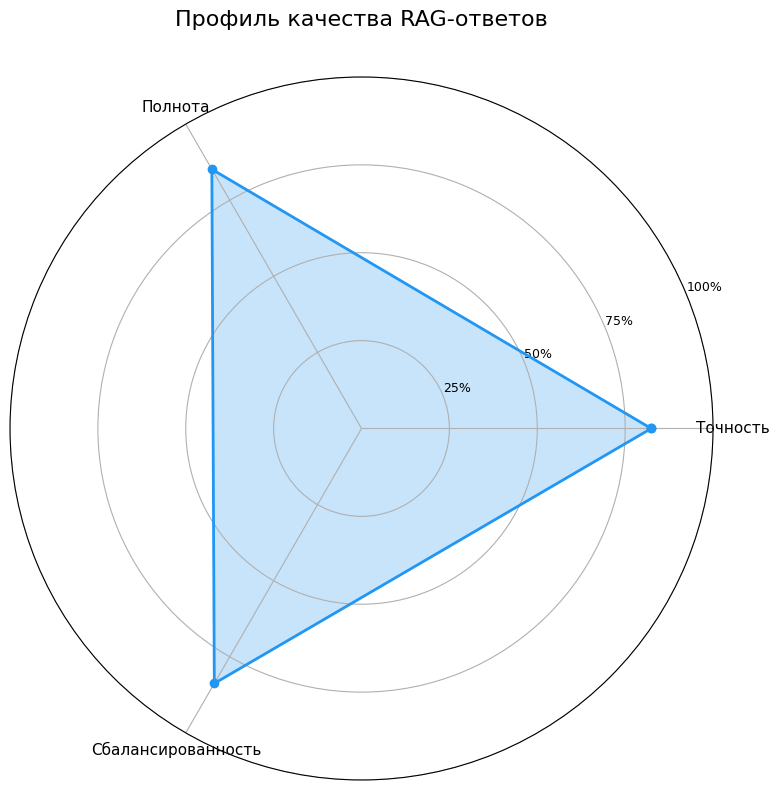

In [76]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Точность', 'Полнота', 'Сбалансированность']
N = len(categories)

values = [bert_scores['precision'],
          bert_scores['recall'],
          bert_scores['f1'],
          ]

values += values[:1]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

ax.plot(angles, values, 'o-', linewidth=2, color='#2196F3', label='RAG ответы')
ax.fill(angles, values, alpha=0.25, color='#2196F3')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim([0, 1])
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=9)

plt.title('Профиль качества RAG-ответов\n', size=16, pad=20)

plt.tight_layout()
plt.show()

In [77]:
print("Выводы из Bertscore:")
print(f"F1-score: {bert_scores['f1']:.3f} ({bert_scores['f1']:.1%})")
print(f"Ответы семантически близки, RAG сохраняет суть")
print()
print(f"Recall: {bert_scores['recall']:.3f} ({bert_scores['recall']:.1%})")
print(f"RAG сохраняет {bert_scores['recall']:.0%} важной информации из обычных ответов")
print()
print(f"Precision: {bert_scores['precision']:.3f} ({bert_scores['precision']:.1%})")
print(f"{bert_scores['precision']:.0%} информации в RAG достоверны")
print()
print("Итог:")
print("RAG Даёт более детализированные ответы")
print("Активно использует контекст из научных статей")
print("Сохраняет баланс между новизной и достоверностью")

Выводы из Bertscore:
F1-score: 0.838 (83.8%)
Ответы семантически близки, RAG сохраняет суть

Recall: 0.852 (85.2%)
RAG сохраняет 85% важной информации из обычных ответов

Precision: 0.824 (82.4%)
82% информации в RAG достоверны

Итог:
RAG Даёт более детализированные ответы
Активно использует контекст из научных статей
Сохраняет баланс между новизной и достоверностью


In [21]:
import pickle

system_state = {
    'model': model,
    'index': index,
    'df_chunks': df_chunks,
    'flan_model': flan_model,
    'flan_tokenizer': flan_tokenizer,
    'category': CATEGORY,
    'num_papers': len(df),
    'num_chunks': len(df_chunks)
}

with open('eess_iv_rag_system.pkl', 'wb') as f:
    pickle.dump(system_state, f)

print(f"   - Категория: {CATEGORY}")
print(f"   - Количество статей: {len(df)}")
print(f"   - Количество чанков: {len(df_chunks)}")
print(f"   - Размер векторного индекса: {index.ntotal}")

   - Категория: eess.IV
   - Количество статей: 250
   - Количество чанков: 250
   - Размер векторного индекса: 250
